## Laboratorio 6
### KNN

**Preparar el entorno**

In [13]:
# Librerias que se van a usar

import importlib, subprocess, sys

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "pyreadr": "pyreadr",
    "seaborn": "seaborn"
}

# Si falta alguna libreria, se instala en el momento
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        importlib.import_module(module)

from sklearn.linear_model import BayesianRidge
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pyreadr

**Cargar dataset y dividirlo**

In [14]:
# Se carga el dataset desde el archivo .RData
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Se limpia la columna price (se quitan simbolos y se dejan solo numeros)
df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)

# Se convierte price a numerico
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Se conservan solo filas con precio valido
n_before = len(df)
mask_valid_price = df['price'].notna() & (df['price'] > 0)
df_clean = df.loc[mask_valid_price].copy()
n_after = len(df_clean)
print(f"Filas totales: {n_before}, después limpieza price: {n_after} (eliminadas {n_before-n_after})")

# Se trabaja con log(price) para modelar y visualizar los resultados de mejor manera
df_model = df_clean.copy()
df_model['log_price'] = np.log(df_model['price'])

# Se asegura que estas columnas esten en formato numerico
for col in ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Variables base del modelo
features = ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
X = df_model[features].copy()

# Si existe room_type, se pasa a dummies
if 'room_type' in df_model.columns:
    dummies = pd.get_dummies(df_model['room_type'], drop_first=True)
    X = pd.concat([X, dummies], axis=1)

y = df_model['log_price'].copy()

# Se rellenan faltantes con la mediana de cada columna
X = X.fillna(X.median())

# Se mantiene el mismo split que en otros modelos para poder comparar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de los datos")
print(f"Conjunto de Entrenamiento: {X_train.shape[0]} filas.")
print(f"Conjunto de Prueba: {X_test.shape[0]} filas.\n")

Filas totales: 171748, después limpieza price: 76246 (eliminadas 95502)
Dimensiones de los datos
Conjunto de Entrenamiento: 60996 filas.
Conjunto de Prueba: 15250 filas.



## Actividades:
1. Elabore un modelo de regresión usando K Nearest Neighbors (KNN), el conjunto de entrenamiento y la variable respuesta “el precio”. 
Prediga con el modelo y explique los resultados a los que llega. Asegúrese que los conjuntos de entrenamiento y prueba sean los mismos de las entregas anteriores para que los modelos sean comparables.
2. Analice los resultados del modelo de regresión usando KNN. ¿Qué tan bien le fue prediciendo? Utilice las métricas correctas.
3. Compare los resultados con el modelo de regresión lineal, el mejor modelo de árbol de regresión y de naive bayes que hizo en las entregas pasadas. ¿Cuál funcionó mejor?

Modelo de Regresión KNN
R2 (log): 0.4245
MAE (USD): $550.06
RMSE (USD): $3675.89



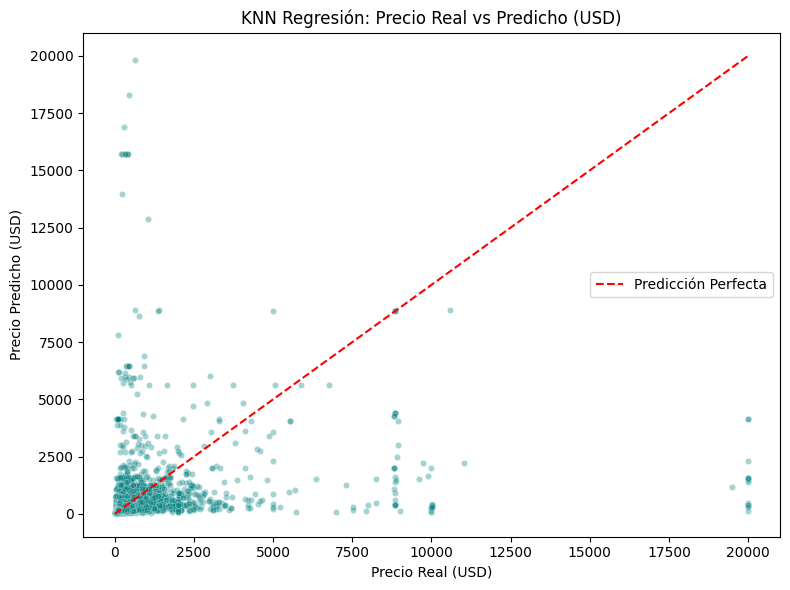

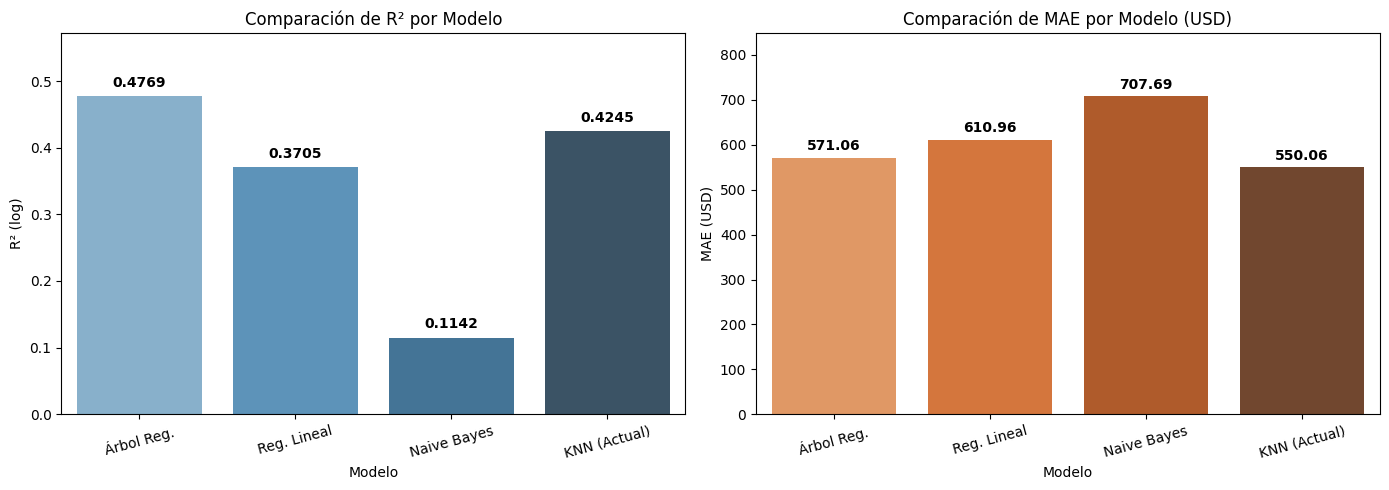

In [15]:
# Escalar los datos para KNN

scaler_reg = StandardScaler()

# X_train y X_test son variables predictoras de labs anteriores.
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print("Modelo de Regresión KNN")

# Se instancia el modelo (k=5 por defecto para este primer acercamiento)
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)  # y_train es log_price

# Predicción
y_pred_log_knn = knn_reg.predict(X_test_scaled)

# Transformamos de vuelta a dólares para evaluar el MAE y RMSE
y_test_usd = np.exp(y_test).to_numpy()
y_pred_usd_knn = np.exp(y_pred_log_knn)

# Cálculo de métricas
r2_knn_log = r2_score(y_test, y_pred_log_knn)
mae_knn_usd = mean_absolute_error(y_test_usd, y_pred_usd_knn)
rmse_knn_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd_knn))

print(f"R2 (log): {r2_knn_log:.4f}")
print(f"MAE (USD): ${mae_knn_usd:.2f}")
print(f"RMSE (USD): ${rmse_knn_usd:.2f}\n")

# Gráficas

# Primera gráfica
# Recortamos al percentil 99 para que los valores extremos no aplasten la visualización
upper_limit = np.nanpercentile(y_test_usd, 99)
plot_df = pd.DataFrame({'Real_USD': y_test_usd, 'Pred_USD': y_pred_usd_knn}).reset_index(drop=True)
plot_df = plot_df[(plot_df['Real_USD'] <= upper_limit) & (plot_df['Pred_USD'] <= upper_limit)]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='Real_USD', y='Pred_USD', alpha=0.35, s=20, color='teal')
plt.plot([0, upper_limit], [0, upper_limit], '--r', linewidth=1.5, label='Predicción Perfecta')
plt.title('KNN Regresión: Precio Real vs Predicho (USD)')
plt.xlabel('Precio Real (USD)')
plt.ylabel('Precio Predicho (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# Segunda gráfica
R2_KNN_LOG = r2_knn_log
MAE_KNN_USD = mae_knn_usd

modelos = ['Árbol Reg.', 'Reg. Lineal', 'Naive Bayes', 'KNN (Actual)']
r2_scores = [0.4769, 0.3705, 0.1142, R2_KNN_LOG]
mae_scores = [571.06, 610.96, 707.69, MAE_KNN_USD]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: R2
r2_df = pd.DataFrame({'Modelo': modelos, 'R2': r2_scores})
sns.barplot(data=r2_df, x='Modelo', y='R2', hue='Modelo', dodge=False, legend=False,
            ax=axes[0], palette='Blues_d')
axes[0].set_title('Comparación de R² por Modelo')
axes[0].set_ylabel('R² (log)')
axes[0].set_ylim(0, max(r2_scores) * 1.2)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

# Panel 2: MAE
mae_df = pd.DataFrame({'Modelo': modelos, 'MAE': mae_scores})
sns.barplot(data=mae_df, x='Modelo', y='MAE', hue='Modelo', dodge=False, legend=False,
            ax=axes[1], palette='Oranges_d')
axes[1].set_title('Comparación de MAE por Modelo (USD)')
axes[1].set_ylabel('MAE (USD)')
axes[1].set_ylim(0, max(mae_scores) * 1.2)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 10, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

4. Haga un modelo de clasificación, use la variable categórica que hizo con el precio de las casas (barata, media y cara) como variable respuesta.

In [16]:
# Agregar nuevamente la variable categórica de precio

limites = df_model['price'].quantile([0.33, 0.66]).values
p33, p66 = limites[0], limites[1]

def definir_segmento(precio):
    if precio <= p33:
        return 'Económica'
    elif precio <= p66:
        return 'Intermedia'
    return 'Cara'

df_model['categoria_precio'] = df_model['price'].apply(definir_segmento)

features_clas = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'number_of_reviews',
    'review_scores_rating'
]

for col in features_clas:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

X_clas = df_model[features_clas].copy()

if 'room_type' in df_model.columns:
    room_type_dummies = pd.get_dummies(df_model['room_type'], prefix='room_type', drop_first=True)
    X_clas = pd.concat([X_clas, room_type_dummies], axis=1)

X_clas = X_clas.fillna(X_clas.median(numeric_only=True))
y_clas = df_model['categoria_precio'].copy()

# Se reutiliza exactamente el mismo split del modelo de regresion
train_idx = X_train.index
test_idx = X_test.index

X_train_c = X_clas.loc[train_idx].copy()
X_test_c = X_clas.loc[test_idx].copy()
y_train_c = y_clas.loc[train_idx].copy()
y_test_c = y_clas.loc[test_idx].copy()

labels_orden = ['Económica', 'Intermedia', 'Cara']
modelo_nb_clas = GaussianNB()
modelo_nb_clas.fit(X_train_c, y_train_c)
y_pred_c = modelo_nb_clas.predict(X_test_c)

distribucion_categorias = df_model['categoria_precio'].value_counts().reindex(labels_orden)
distribucion_pct = (df_model['categoria_precio'].value_counts(normalize=True).reindex(labels_orden) * 100).round(2)
split_consistente = X_train_c.index.equals(train_idx) and X_test_c.index.equals(test_idx)

print('Puntos de corte seleccionados para la variable respuesta:')
print(f'- Económica (barata): price <= ${p33:.2f}')
print(f'- Intermedia (media): ${p33:.2f} < price <= ${p66:.2f}')
print(f'- Cara: price > ${p66:.2f}')
print('\nDistribución de la nueva variable respuesta:')
for categoria in labels_orden:
    print(f'- {categoria}: {int(distribucion_categorias[categoria])} observaciones ({distribucion_pct[categoria]:.2f}%)')
print('\nPredictores utilizados para clasificación:')
print(X_clas.columns.tolist())
print(f'\nFilas de entrenamiento: {X_train_c.shape[0]} | Filas de prueba: {X_test_c.shape[0]}')
print(f'Se reutilizó el mismo split que en regresión: {split_consistente}')

Puntos de corte seleccionados para la variable respuesta:
- Económica (barata): price <= $141.00
- Intermedia (media): $141.00 < price <= $264.00
- Cara: price > $264.00

Distribución de la nueva variable respuesta:
- Económica: 25185 observaciones (33.03%)
- Intermedia: 25164 observaciones (33.00%)
- Cara: 25897 observaciones (33.97%)

Predictores utilizados para clasificación:
['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']

Filas de entrenamiento: 60996 | Filas de prueba: 15250
Se reutilizó el mismo split que en regresión: True


In [17]:
print("Actividad 4: Entrenamiento del Modelo de Clasificación KNN")

# 1. Escalar los datos (para que KNN mida bien las distancias)
scaler_clas = StandardScaler()
X_train_c_scaled = scaler_clas.fit_transform(X_train_c)
X_test_c_scaled = scaler_clas.transform(X_test_c)

# 2. Instanciar y entrenar el modelo (usamos k=5 como base inicial)
knn_clas = KNeighborsClassifier(n_neighbors=5)
knn_clas.fit(X_train_c_scaled, y_train_c)
print("Modelo entrenado exitosamente con los datos escalados.\n")

Actividad 4: Entrenamiento del Modelo de Clasificación KNN
Modelo entrenado exitosamente con los datos escalados.



5. Utilice los modelos con el conjunto de prueba y determine la eficiencia del algoritmo para predecir y clasificar

Actividad 5: Evaluación en el Conjunto de Prueba
Accuracy Global en Prueba: 0.5653
Baseline (Clase Mayoritaria): 0.3371

Reporte de Clasificación:
              precision    recall  f1-score   support

   Económica       0.61      0.65      0.63      4983
  Intermedia       0.47      0.35      0.40      5126
        Cara       0.59      0.70      0.64      5141

    accuracy                           0.57     15250
   macro avg       0.56      0.57      0.56     15250
weighted avg       0.55      0.57      0.56     15250



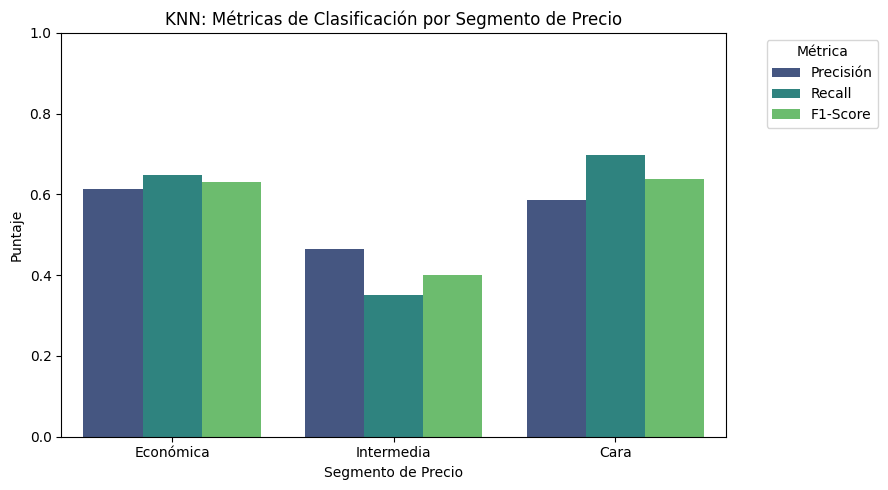

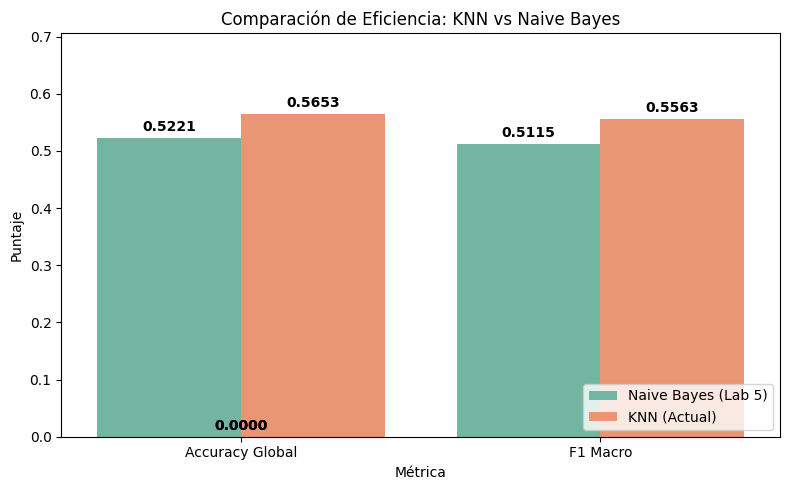

In [18]:
print("Actividad 5: Evaluación en el Conjunto de Prueba")

# Predicción
y_pred_c_knn = knn_clas.predict(X_test_c_scaled)

# Cálculo de Exactitud (Accuracy) y Baseline
accuracy_knn_clas = accuracy_score(y_test_c, y_pred_c_knn)
labels_orden = ['Económica', 'Intermedia', 'Cara']
baseline_mayoritaria = y_test_c.value_counts(normalize=True).loc[labels_orden].max()

print(f"Accuracy Global en Prueba: {accuracy_knn_clas:.4f}")
print(f"Baseline (Clase Mayoritaria): {baseline_mayoritaria:.4f}\n")

# Reporte detallado para extraer F1, Precision y Recall
reporte_clas_knn = classification_report(
    y_test_c,
    y_pred_c_knn,
    labels=labels_orden,
    zero_division=0
)
print("Reporte de Clasificación:")
print(reporte_clas_knn)

## Gráficas:

# Gráfica 1
reporte_dict_knn = classification_report(
    y_test_c,
    y_pred_c_knn,
    output_dict=True,
    labels=labels_orden,
    zero_division=0
)

metricas_cat = pd.DataFrame({
    'Categoría': labels_orden,
    'Precisión': [reporte_dict_knn[cat]['precision'] for cat in labels_orden],
    'Recall': [reporte_dict_knn[cat]['recall'] for cat in labels_orden],
    'F1-Score': [reporte_dict_knn[cat]['f1-score'] for cat in labels_orden]
})

metricas_melted = metricas_cat.melt(id_vars='Categoría', var_name='Métrica', value_name='Puntaje')

plt.figure(figsize=(9, 5))
sns.barplot(
    data=metricas_melted,
    x='Categoría',
    y='Puntaje',
    hue='Métrica',
    palette='viridis',
    order=labels_orden,
    hue_order=['Precisión', 'Recall', 'F1-Score']
)
plt.title('KNN: Métricas de Clasificación por Segmento de Precio')
plt.ylim(0, 1)
plt.xlabel('Segmento de Precio')
plt.ylabel('Puntaje')
plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Gráfica 2
# Valores documentados de Naive Bayes del Lab 5
acc_nb = 0.5221
f1_nb = 0.5115

comp_df = pd.DataFrame({
    'Modelo': ['Naive Bayes (Lab 5)', 'KNN (Actual)', 'Naive Bayes (Lab 5)', 'KNN (Actual)'],
    'Métrica': ['Accuracy Global', 'Accuracy Global', 'F1 Macro', 'F1 Macro'],
    'Puntaje': [acc_nb, accuracy_knn_clas, f1_nb, reporte_dict_knn['macro avg']['f1-score']]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=comp_df, x='Métrica', y='Puntaje', hue='Modelo', palette='Set2')
plt.title('Comparación de Eficiencia: KNN vs Naive Bayes')
plt.ylim(0, max(comp_df['Puntaje']) * 1.25)

# Añadir etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.4f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold'
    )

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()